## Script for statistics of binary relevance and classifier chains of benchmarks


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score

In [3]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



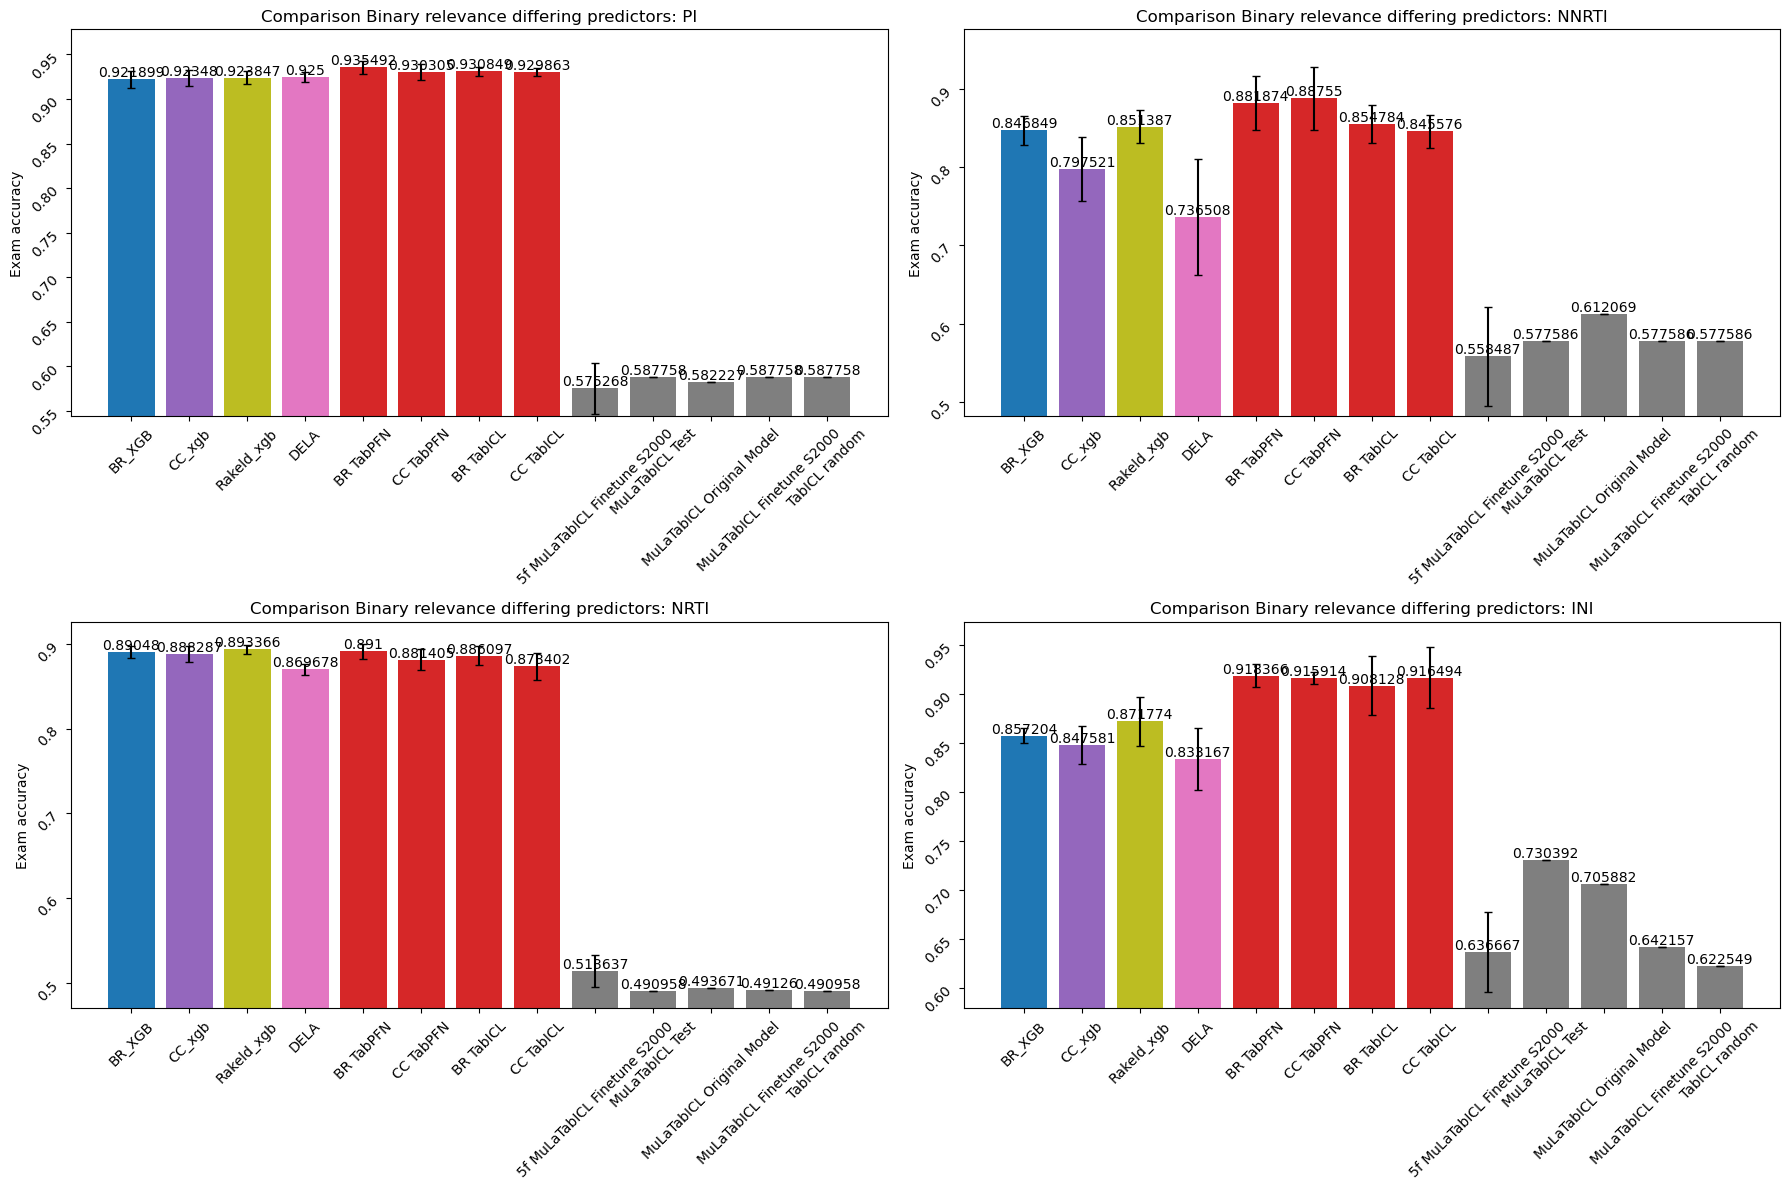

In [8]:


ml_models = ["BR_XGB", "CC_xgb"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})

files1 = ["Rakeld_xgb", "DELA"]

for path in filepath_list_ml:
    acc_list_mean = []
    acc_list_std = []

    for file in files1:
        results = pd.read_csv(path + file + ending)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


files = ["Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_prediction_new_save.csv", "Classifier_Chain_5_fold_tabicl_prediction_woNaN_new_save.csv", "MuLaTabICL_finetune_step2000_5_fold.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


MuLaTabICL_list = ["MuLaTabICL.csv", "MuLaTabICL_orig_model.csv", "MuLaTabICL_finetune_step2000.csv", "MuLaTabICL_random_step1.csv"]

for path in filepath_list:

    for mula in MuLaTabICL_list:
        results = pd.read_csv(path + mula)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = result_handler.exam_acc(pred_labels, true_labels)

        sub_accs_fold_mean[path.split("/")[-1].strip("_")].append(sub_acc)
        sub_accs_fold_std[path.split("/")[-1].strip("_")].append(0)



df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN", "CC TabPFN", "BR TabICL", "CC TabICL", "5f MuLaTabICL Finetune S2000", "MuLaTabICL Test", "MuLaTabICL Original Model", "MuLaTabICL Finetune S2000", "TabICL random"]

color = ["tab:blue"] + ["tab:purple"] + ["tab:olive"] + ["tab:pink"] + ["tab:red"] * 4 + ["tab:gray"] * 5

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + files1 + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

#plt.savefig("../figures/All_benchmark_comparison_examAcc_wTabICL_wo_NaN.png")
